<a href="https://colab.research.google.com/github/np03cs4a240372-tech/AI/blob/main/Worksheet_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Worksheet 10 – Naive Bayes and Feature Selection  
**Course:** 5CS037 – Concepts and Technologies of AI  




## 0. Environment Setup  
We begin by installing required libraries and importing all necessary packages.


In [2]:

!pip install nltk


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True


## Exercise 1 – Naive Bayes Sentiment Analysis (IMDB Dataset)

**Objective:**  
Build a sentiment analysis model to classify movie reviews as **positive** or **negative**
using the IMDB Movie Review Dataset.



### 1. Data Loading and Preprocessing

Steps performed:
- Convert text to lowercase  
- Remove punctuation and non-alphabetic characters  
- Tokenize text  
- Remove stopwords  
- Apply stemming


In [5]:

# Load IMDB dataset
IMDB_PATH = '/content/drive/MyDrive/ConceptAndTechnologiesOfAI/IMDB Dataset.csv'
imdb = pd.read_csv(IMDB_PATH)

# Convert target labels
imdb['sentiment'] = imdb['sentiment'].map({'positive': 1, 'negative': 0})

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = [stemmer.stem(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

imdb['clean_review'] = imdb['review'].apply(preprocess_text)
imdb.head()


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,1,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,1,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,0,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visual stun film...



### 2. Train-Test Split (80% Training, 20% Testing)


In [6]:

X = imdb['clean_review']
y = imdb['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



### 3. Feature Extraction and Naive Bayes Training

We use:
- **Bag-of-Words** representation (CountVectorizer)
- **Multinomial Naive Bayes** classifier


In [7]:

vectorizer = CountVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred = nb_model.predict(X_test_vec)
y_prob = nb_model.predict_proba(X_test_vec)[:, 1]



### 4. Model Evaluation

Metrics used:
- Accuracy  
- Precision  
- Recall  
- F1-Score  
- Confusion Matrix  
- ROC-AUC Curve


Accuracy: 0.8427
Precision: 0.8455333736640451
Recall: 0.8386
F1-Score: 0.8420524149010945
ROC-AUC: 0.9107094800000001

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      5000
           1       0.85      0.84      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



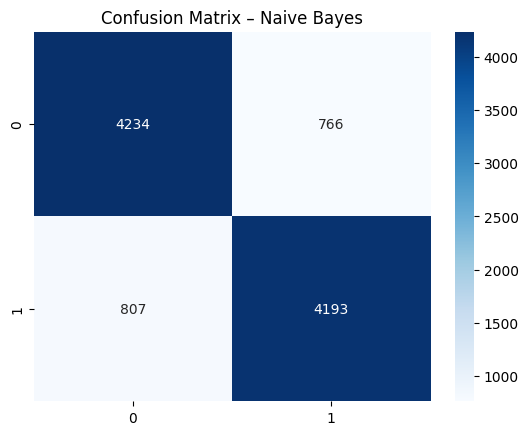

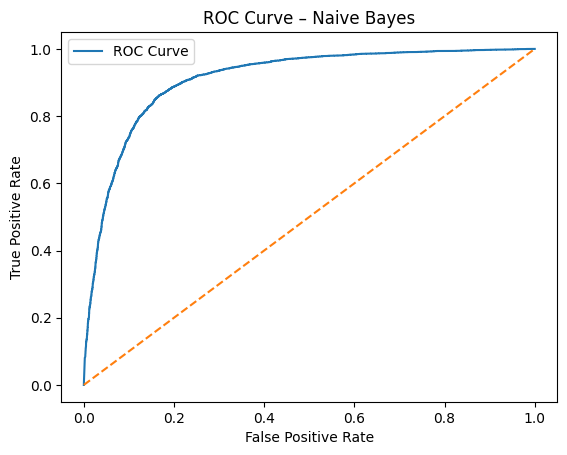

In [8]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Naive Bayes")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Naive Bayes")
plt.legend()
plt.show()



## Feature Selection Exercise – Breast Cancer Prognostic Dataset

**Objective:**  
Identify the most important features using a **wrapper method (RFE)** and evaluate
model performance.



### 1. Data Loading and Exploratory Data Analysis


In [9]:

# Load Breast Cancer Prognostic dataset
BC_PATH = '/content/drive/MyDrive/ConceptAndTechnologiesOfAI/breast_cancer_prognostic.csv'
bc = pd.read_csv(BC_PATH)

bc.describe()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,target
count,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000
mean,14.587500,20.150000,94.925000,665.075000,0.09750,0.143750,0.182500,0.087500,0.178750,0.06125,0.500000
std,2.621034,3.710218,17.605985,236.729694,0.01488,0.050973,0.083964,0.043997,0.029001,0.01126,0.534522
min,11.800000,15.600000,75.200000,410.300000,0.08000,0.090000,0.080000,0.040000,0.140000,0.05000,0.000000
25%,12.400000,16.950000,81.350000,467.475000,0.08750,0.100000,0.115000,0.050000,0.157500,0.05000,0.000000
50%,13.900000,19.700000,90.350000,606.100000,0.09500,0.130000,0.170000,0.075000,0.175000,0.06000,0.500000
75%,16.625000,22.850000,107.325000,834.050000,0.11000,0.185000,0.255000,0.125000,0.202500,0.07000,1.000000
max,18.400000,25.800000,121.600000,1003.000000,0.12000,0.220000,0.300000,0.150000,0.220000,0.08000,1.000000



### 2. Preprocessing and Train-Test Split


In [10]:

X = bc.drop('target', axis=1)
y = bc['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)



### 3. Recursive Feature Elimination (RFE)

We select the **top 5 most important features** using Logistic Regression.


In [11]:

log_reg = LogisticRegression(max_iter=500)
rfe = RFE(log_reg, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_features = X.columns[rfe.support_]
print("Selected Features:", list(selected_features))


Selected Features: ['texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean']



### 4. Model Training and Evaluation


In [12]:

X_train_sel = X_train[:, rfe.support_]
X_test_sel = X_test[:, rfe.support_]

log_reg.fit(X_train_sel, y_train)
y_pred = log_reg.predict(X_test_sel)
y_prob = log_reg.predict_proba(X_test_sel)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
ROC-AUC: 1.0



### 5. Experimentation and Discussion

Feature selection reduces dimensionality and often improves model generalization.
Different numbers of selected features can affect performance and complexity.
